# HGP concordance inspection vs PINN

This short notebook inspects the finished hierarchical GP-style concordance product and compares it with the existing PINN concordance fields.

**What this checks**

1. HGP run metadata, holdout calibration and per-band field amplitudes from the JSON sidecar.
2. HGP mean field vs the PINN head-residual field on a common sky grid.
3. HGP posterior uncertainty and coverage maps.
4. The HGP common / Rubin-or-NISP / band-specific decomposition.

The grids are not compared pixel-by-pixel directly: the HGP product is written on a 5 arcsec mesh, while the saved PINN products are on a 1 arcsec mesh. We sample the PINN field at the HGP sky coordinates before comparing vectors.

**Important caveat.** The default comparison below is now apples-to-apples in source catalogue: HGP and PINN both use the CenterNet anchor cache. HGP fits `head_resid`; the default PINN head-residual product was refit from the same `anchors_centernet.npz` cache for this notebook. Differences between HGP and PINN are therefore mainly model/prior differences, with a small remaining difference from each fitter's clipping/weighting choices.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from scipy.ndimage import map_coordinates

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 180,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

ROOT = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
CKPT = ROOT / 'models/checkpoints/latent_position_v8_no_psf'

HGP_FITS = CKPT / 'concordance_hgp_head_resid_richer.fits'
HGP_JSON = CKPT / 'concordance_hgp_head_resid_richer.fits.json'
PINN_HEAD_FITS = CKPT / 'concordance_pinn_centernet_head_resid.fits'
PINN_RAW_FITS = CKPT / 'concordance_pinn_centernet_raw.fits'

BANDS = ['U', 'G', 'R', 'I', 'Z', 'Y', 'NISP_Y', 'NISP_J', 'NISP_H']
BAND_LABEL = {
    'U': 'u', 'G': 'g', 'R': 'r', 'I': 'i', 'Z': 'z', 'Y': 'y',
    'NISP_Y': 'NISP Y', 'NISP_J': 'NISP J', 'NISP_H': 'NISP H',
}

# COVERAGE in these FITS files is distance to the nearest anchor, in arcsec.
# Use a support mask for quantitative comparisons so edge extrapolation does
# not dominate field RMS. Tune these thresholds if you want a stricter mask.
MAX_NEAREST_ANCHOR_ARCSEC = 30.0
MAX_HGP_STD_RADIAL_MAS = 10.0

for path in [HGP_FITS, HGP_JSON, PINN_HEAD_FITS, PINN_RAW_FITS]:
    if not path.exists():
        raise FileNotFoundError(path)

print('HGP:', HGP_FITS.relative_to(ROOT))
print('PINN head residual:', PINN_HEAD_FITS.relative_to(ROOT))
print('PINN raw:', PINN_RAW_FITS.relative_to(ROOT))

HGP: models/checkpoints/latent_position_v8_no_psf/concordance_hgp_head_resid_richer.fits
PINN head residual: models/checkpoints/latent_position_v8_no_psf/concordance_pinn_centernet_head_resid.fits
PINN raw: models/checkpoints/latent_position_v8_no_psf/concordance_pinn_centernet_raw.fits


In [2]:
def product_header_summary(path, band='I'):
    with fits.open(path, memmap=True) as hdul:
        primary = hdul[0].header
        h = hdul[f'{band}.DRA'].header
        return {
            'product': path.name,
            'method_primary': primary.get('METHOD', ''),
            'method_band': h.get('METHOD', ''),
            'anchors': primary.get('ANCHORS', ''),
            'offset_kind': primary.get('OFFKIND', ''),
            'n_anchor_primary': primary.get('NANCHOR', np.nan),
            'n_anchor_band': h.get('NANCHORS', h.get('NSRC', np.nan)),
            'dstep_arcsec': h.get('DSTEP', primary.get('DSTEP', np.nan)),
            'shape': (h['NAXIS2'], h['NAXIS1']),
            'ra0': h.get('RA0', h.get('CRVAL1', np.nan)),
            'dec0': h.get('DEC0', h.get('CRVAL2', np.nan)),
        }


product_df = pd.DataFrame([
    product_header_summary(HGP_FITS),
    product_header_summary(PINN_HEAD_FITS),
    product_header_summary(PINN_RAW_FITS),
])
display(product_df)

,product,method_primary,method_band,anchors,offset_kind,n_anchor_primary,n_anchor_band,dstep_arcsec,shape,ra0,dec0
0,concordance_hgp_head_resid_richer.fits,hier_basis_gp,hier_basis_gp,anchors_centernet.npz,head_resid,453038.0,453038,5.0,"(367, 256)",53.090061,-28.125319
1,concordance_pinn_centernet_head_resid.fits,,direct_pinn,,,NaN,439058,5.0,"(366, 255)",53.089828,-28.126095
2,concordance_pinn_centernet_raw.fits,,direct_pinn,,,NaN,481990,5.0,"(366, 255)",53.090302,-28.124947


## 1. HGP run summary

The sidecar JSON is the quickest sanity check: it records which anchors were used, which residual was fitted, what length scales were available, and whether the posterior uncertainty was calibrated on a spatial holdout.

In [3]:
with HGP_JSON.open() as f:
    hgp_meta = json.load(f)

args = hgp_meta['args']
train = hgp_meta['train']
holdout = hgp_meta.get('holdout', {})
basis = hgp_meta['basis']

run_summary = pd.Series({
    'anchors': args['anchors'],
    'offset_kind': args['offset_kind'],
    'pool': args['pool'],
    'n_anchors': hgp_meta['n_anchors'],
    'n_features': hgp_meta['hierarchy']['n_features'],
    'length_scales_arcsec': args['length_scales'],
    'mesh_shape': tuple(hgp_meta['output']['mesh_shape']),
    'dstep_arcsec': args['dstep_arcsec'],
    'train_resid_med_mas': train['train_resid_med_mas'],
    'holdout_resid_med_mas': holdout.get('holdout_resid_med_mas', np.nan),
    'holdout_z_std_dra': holdout.get('z_std_dra', np.nan),
    'holdout_z_std_ddec': holdout.get('z_std_ddec', np.nan),
    'uncertainty_calibration_factor': holdout.get('uncertainty_calibration_factor', np.nan),
})
display(run_summary.to_frame('value'))

basis_df = pd.DataFrame(basis['scales'])
display(basis_df)

,value
anchors,models/checkpoints/latent_position_v8_no_psf/a...
offset_kind,head_resid
pool,all
n_anchors,453038
n_features,5232
length_scales_arcsec,"45,120,300,900"
mesh_shape,"(367, 256)"
dstep_arcsec,5.0
train_resid_med_mas,7.685241
holdout_resid_med_mas,10.854042


,length_scale_arcsec,spacing_arcsec,n_centers
0,45.0,176.052634,130
1,120.0,201.693631,130
2,300.0,300.000000,120
3,900.0,900.000000,56


,band,n_anchors,hgp_field_rms_mas_json,hgp_median_std_mas_json
0,u,9532,8.850463,5.837331
1,g,42814,7.629612,1.389452
2,r,49726,7.256988,1.210300
3,i,44748,7.551491,1.259015
4,z,32159,7.166272,1.554751
5,y,13680,8.556701,2.791408
6,nisp_Y,82659,5.763717,1.013536
7,nisp_J,90226,5.428207,0.979398
8,nisp_H,87494,5.309132,0.993795


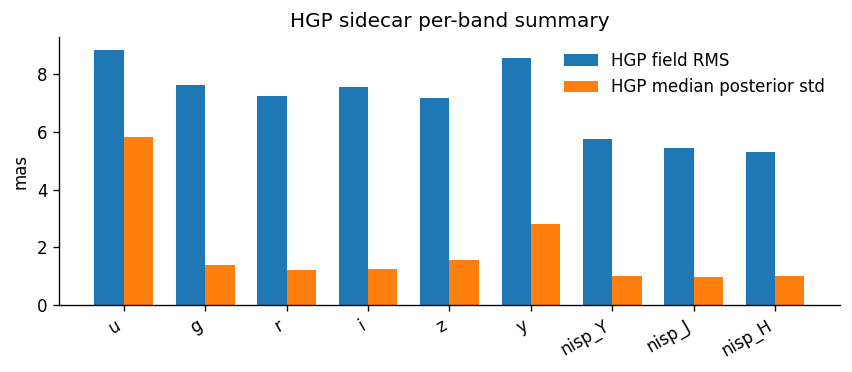

In [4]:
band_rows = []
for band, vals in hgp_meta['output']['bands'].items():
    band_rows.append({
        'band': band,
        'n_anchors': vals['n_anchors'],
        'hgp_field_rms_mas_json': vals['field_rms_mas'],
        'hgp_median_std_mas_json': vals['median_std_mas'],
    })
hgp_band_json = pd.DataFrame(band_rows)
display(hgp_band_json)

fig, ax = plt.subplots(figsize=(7.2, 3.2))
x = np.arange(len(hgp_band_json))
ax.bar(x - 0.18, hgp_band_json['hgp_field_rms_mas_json'], width=0.36, label='HGP field RMS')
ax.bar(x + 0.18, hgp_band_json['hgp_median_std_mas_json'], width=0.36, label='HGP median posterior std')
ax.set_xticks(x, hgp_band_json['band'], rotation=30, ha='right')
ax.set_ylabel('mas')
ax.set_title('HGP sidecar per-band summary')
ax.legend(frameon=False)
fig.tight_layout()

## 2. Compare HGP and PINN on the same sky grid

For each band, use the HGP WCS as the target grid and interpolate the PINN maps at those exact sky positions. All FITS values are in arcsec; the summary table reports milliarcseconds.

In [5]:
def grid_world_from_header(header):
    h = int(header['NAXIS2'])
    w = int(header['NAXIS1'])
    yy, xx = np.mgrid[:h, :w]
    ra, dec = WCS(header).wcs_pix2world(xx, yy, 0)
    return ra, dec


def sample_image_at_world(hdu, ra, dec, order=1):
    data = np.asarray(hdu.data, dtype=np.float64)
    x, y = WCS(hdu.header).wcs_world2pix(ra, dec, 0)
    sampled = map_coordinates(
        data,
        [y.ravel(), x.ravel()],
        order=order,
        mode='constant',
        cval=np.nan,
    ).reshape(ra.shape)
    return sampled


def amp_mas(dra_arcsec, dde_arcsec):
    return np.hypot(dra_arcsec, dde_arcsec) * 1000.0


def rms_amp_mas(dra_arcsec, dde_arcsec, mask=None):
    a = amp_mas(dra_arcsec, dde_arcsec)
    if mask is not None:
        a = a[mask]
    return float(np.sqrt(np.nanmean(a ** 2))) if np.isfinite(a).any() else np.nan


def median_amp_mas(dra_arcsec, dde_arcsec, mask=None):
    a = amp_mas(dra_arcsec, dde_arcsec)
    if mask is not None:
        a = a[mask]
    return float(np.nanmedian(a)) if np.isfinite(a).any() else np.nan


def load_resampled_band(band):
    with fits.open(HGP_FITS, memmap=True) as hgp, \
         fits.open(PINN_HEAD_FITS, memmap=True) as pinn_head, \
         fits.open(PINN_RAW_FITS, memmap=True) as pinn_raw:
        h_hdu = hgp[f'{band}.DRA']
        ra, dec = grid_world_from_header(h_hdu.header)
        out = {
            'ra': ra,
            'dec': dec,
            'hgp_dra': np.asarray(hgp[f'{band}.DRA'].data, dtype=np.float64),
            'hgp_dde': np.asarray(hgp[f'{band}.DDE'].data, dtype=np.float64),
            'hgp_dra_std': np.asarray(hgp[f'{band}.DRA_STD'].data, dtype=np.float64),
            'hgp_dde_std': np.asarray(hgp[f'{band}.DDE_STD'].data, dtype=np.float64),
            'hgp_coverage': np.asarray(hgp['COVERAGE'].data, dtype=np.float64) if 'COVERAGE' in hgp else np.ones_like(ra),
            'pinn_head_dra': sample_image_at_world(pinn_head[f'{band}.DRA'], ra, dec),
            'pinn_head_dde': sample_image_at_world(pinn_head[f'{band}.DDE'], ra, dec),
            'pinn_head_coverage': sample_image_at_world(pinn_head['COVERAGE'], ra, dec) if 'COVERAGE' in pinn_head else np.ones_like(ra),
            'pinn_raw_dra': sample_image_at_world(pinn_raw[f'{band}.DRA'], ra, dec),
            'pinn_raw_dde': sample_image_at_world(pinn_raw[f'{band}.DDE'], ra, dec),
        }
    return out


def finite_mask(d):
    finite = np.isfinite(d['hgp_dra']) & np.isfinite(d['hgp_dde'])
    finite &= np.isfinite(d['pinn_head_dra']) & np.isfinite(d['pinn_head_dde'])
    finite &= np.isfinite(d['pinn_raw_dra']) & np.isfinite(d['pinn_raw_dde'])
    finite &= np.isfinite(d['hgp_coverage']) & np.isfinite(d['pinn_head_coverage'])
    return finite


def support_mask(d, max_anchor_dist_arcsec=MAX_NEAREST_ANCHOR_ARCSEC, max_hgp_std_mas=MAX_HGP_STD_RADIAL_MAS):
    mask = finite_mask(d)
    mask &= d['hgp_coverage'] <= max_anchor_dist_arcsec
    mask &= d['pinn_head_coverage'] <= max_anchor_dist_arcsec
    if max_hgp_std_mas is not None:
        mask &= amp_mas(d['hgp_dra_std'], d['hgp_dde_std']) <= max_hgp_std_mas
    return mask

In [6]:
rows = []
for band in BANDS:
    d = load_resampled_band(band)
    m_full = finite_mask(d)
    m = support_mask(d)
    diff_dra = d['hgp_dra'] - d['pinn_head_dra']
    diff_dde = d['hgp_dde'] - d['pinn_head_dde']
    std_radial = amp_mas(d['hgp_dra_std'], d['hgp_dde_std'])
    rows.append({
        'band': BAND_LABEL[band],
        'n_full': int(m_full.sum()),
        'n_support': int(m.sum()),
        'support_frac': float(m.sum() / max(m_full.sum(), 1)),
        'hgp_rms_full_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m_full),
        'hgp_median_support_mas': median_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
        'hgp_rms_support_mas': rms_amp_mas(d['hgp_dra'], d['hgp_dde'], m),
        'pinn_head_rms_support_mas': rms_amp_mas(d['pinn_head_dra'], d['pinn_head_dde'], m),
        'hgp_minus_pinn_rms_support_mas': rms_amp_mas(diff_dra, diff_dde, m),
        'hgp_median_std_support_mas': float(np.nanmedian(std_radial[m])),
        'pinn_raw_rms_support_mas': rms_amp_mas(d['pinn_raw_dra'], d['pinn_raw_dde'], m),
    })

compare_df = pd.DataFrame(rows)
display(compare_df.round(3))

,band,n_full,n_support,support_frac,hgp_rms_full_mas,hgp_median_support_mas,hgp_rms_support_mas,pinn_head_rms_support_mas,hgp_minus_pinn_rms_support_mas,hgp_median_std_support_mas,pinn_raw_rms_support_mas
0,u,92227,79487,0.862,8.462,5.105,6.168,1.176,6.181,5.516,5.802
1,g,92227,85281,0.925,7.115,2.188,3.009,0.787,2.857,1.346,4.618
2,r,92227,85299,0.925,6.729,1.924,2.626,0.830,2.466,1.174,4.614
3,i,92227,85283,0.925,7.000,1.919,2.637,0.846,2.455,1.222,5.018
4,z,92227,85229,0.924,6.685,2.280,3.070,0.983,2.822,1.508,4.636
5,y,92227,84750,0.919,8.143,4.093,5.433,1.410,5.045,2.687,4.274
6,NISP Y,92227,85414,0.926,5.383,1.303,1.745,0.853,1.520,0.986,7.130
7,NISP J,92227,85414,0.926,5.083,1.260,1.702,0.889,1.463,0.954,7.403
8,NISP H,92227,85413,0.926,4.950,1.240,1.689,0.805,1.484,0.968,6.856


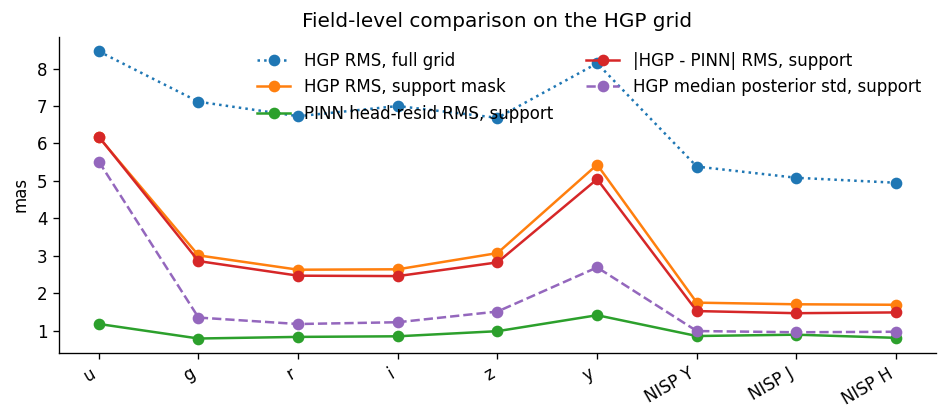

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(compare_df))
ax.plot(x, compare_df['hgp_rms_full_mas'], marker='o', linestyle=':', label='HGP RMS, full grid')
ax.plot(x, compare_df['hgp_rms_support_mas'], marker='o', label='HGP RMS, support mask')
ax.plot(x, compare_df['pinn_head_rms_support_mas'], marker='o', label='PINN head-resid RMS, support')
ax.plot(x, compare_df['hgp_minus_pinn_rms_support_mas'], marker='o', label='|HGP - PINN| RMS, support')
ax.plot(x, compare_df['hgp_median_std_support_mas'], marker='o', linestyle='--', label='HGP median posterior std, support')
ax.set_xticks(x, compare_df['band'], rotation=30, ha='right')
ax.set_ylabel('mas')
ax.set_title('Field-level comparison on the HGP grid')
ax.legend(frameon=False, ncol=2)
fig.tight_layout()

## 3. Map view for one band

Use this as the visual sanity check. The selected band defaults to Rubin `i`, but any entry from `BANDS` above can be used.

Text(0.5, 1.02, 'i: HGP vs PINN on the HGP grid')

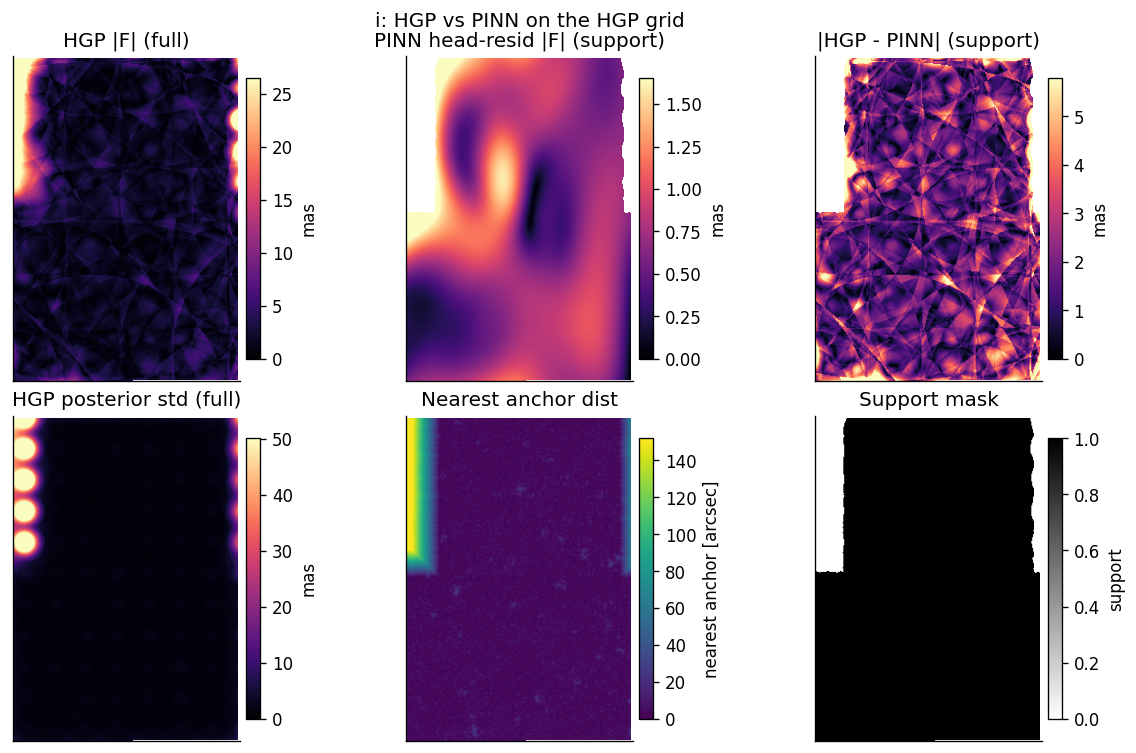

In [8]:
PLOT_BAND = 'I'
d = load_resampled_band(PLOT_BAND)
m_full = finite_mask(d)
m = support_mask(d)

maps = {
    'HGP |F| (full)': (amp_mas(d['hgp_dra'], d['hgp_dde']), m_full, 'mas'),
    'PINN head-resid |F| (support)': (amp_mas(d['pinn_head_dra'], d['pinn_head_dde']), m, 'mas'),
    '|HGP - PINN| (support)': (amp_mas(d['hgp_dra'] - d['pinn_head_dra'], d['hgp_dde'] - d['pinn_head_dde']), m, 'mas'),
    'HGP posterior std (full)': (amp_mas(d['hgp_dra_std'], d['hgp_dde_std']), m_full, 'mas'),
    'Nearest anchor dist': (d['hgp_coverage'], m_full, 'arcsec'),
    'Support mask': (m.astype(float), m_full, 'mask'),
}

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for ax, (title, (image, mask, unit)) in zip(axes.ravel(), maps.items()):
    show = np.asarray(image, dtype=np.float64).copy()
    show[~mask] = np.nan
    if unit == 'arcsec':
        vmin, vmax, cmap = 0, np.nanpercentile(show, 99), 'viridis'
        label = 'nearest anchor [arcsec]'
    elif unit == 'mask':
        vmin, vmax, cmap = 0, 1, 'gray_r'
        label = 'support'
    else:
        vmin, vmax, cmap = 0, np.nanpercentile(show, 98), 'magma'
        label = 'mas'
    im = ax.imshow(show, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, label=label)

fig.suptitle(f'{BAND_LABEL[PLOT_BAND]}: HGP vs PINN on the HGP grid', y=1.02)

Text(0.5, 0.98, 'i vector-component agreement')

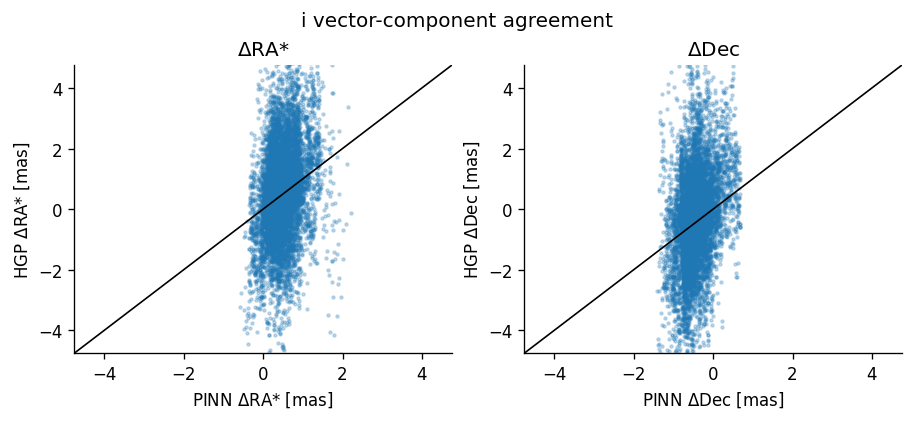

In [9]:
rng = np.random.default_rng(42)
idx = np.flatnonzero(m.ravel())
idx = rng.choice(idx, size=min(8000, idx.size), replace=False)

hgp_dra = d['hgp_dra'].ravel()[idx] * 1000
hgp_dde = d['hgp_dde'].ravel()[idx] * 1000
pinn_dra = d['pinn_head_dra'].ravel()[idx] * 1000
pinn_dde = d['pinn_head_dde'].ravel()[idx] * 1000

lim = np.nanpercentile(np.abs(np.r_[hgp_dra, hgp_dde, pinn_dra, pinn_dde]), 99)
lim = max(lim, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.4), constrained_layout=True)
for ax, hgp_val, pinn_val, name in [
    (axes[0], hgp_dra, pinn_dra, r'$\Delta$RA*'),
    (axes[1], hgp_dde, pinn_dde, r'$\Delta$Dec'),
]:
    ax.scatter(pinn_val, hgp_val, s=3, alpha=0.25, rasterized=True)
    ax.plot([-lim, lim], [-lim, lim], color='black', lw=1)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(f'PINN {name} [mas]')
    ax.set_ylabel(f'HGP {name} [mas]')
    ax.set_title(name)
fig.suptitle(f'{BAND_LABEL[PLOT_BAND]} vector-component agreement')

## 4. HGP hierarchical decomposition

This is the main thing PINN did not give us directly: a split between common, instrument-group and band-specific smooth structure. The numbers below are field RMS values from the HGP output sidecar.

,component,field_rms_mas
10,BAND_NISP_J,0.640897
11,BAND_NISP_H,0.734114
9,BAND_NISP_Y,0.742044
7,BAND_Z,1.643990
2,GROUP_NISP,1.724400
5,BAND_R,1.797363
4,BAND_G,1.818616
6,BAND_I,1.859808
1,GROUP_RUBIN,2.283051
8,BAND_Y,3.585136


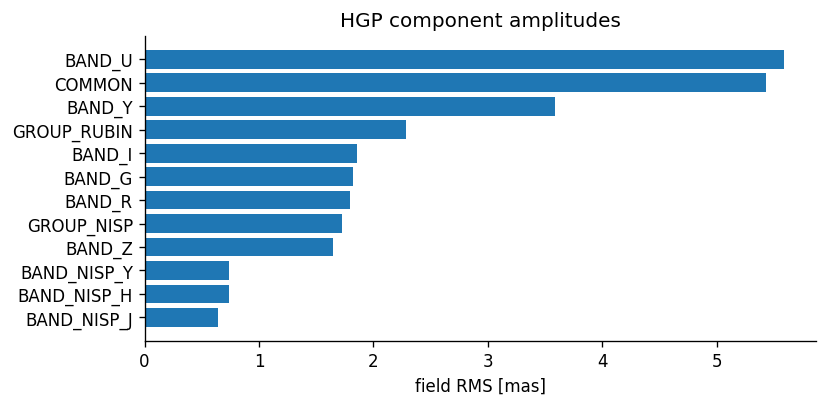

In [10]:
component_df = (
    pd.DataFrame([
        {'component': name, 'field_rms_mas': vals['field_rms_mas']}
        for name, vals in hgp_meta['output'].get('components', {}).items()
    ])
    .sort_values('field_rms_mas', ascending=True)
)
display(component_df)

fig, ax = plt.subplots(figsize=(7, max(3.5, 0.22 * len(component_df))))
ax.barh(component_df['component'], component_df['field_rms_mas'])
ax.set_xlabel('field RMS [mas]')
ax.set_title('HGP component amplitudes')
fig.tight_layout()

## 5. Anchor-level zero-field sanity check

A smooth field should improve the residuals at the actual anchors, not only make a visually structured map. This cell samples HGP and PINN at the CenterNet head-residual anchor positions and compares both to the zero-field baseline. If the median residual barely changes, the fitted smooth field is below the source-level noise floor.

In [11]:
ANCHORS = CKPT / 'anchors_centernet.npz'
BAND_KEY = {'U': 'u', 'G': 'g', 'R': 'r', 'I': 'i', 'Z': 'z', 'Y': 'y',
            'NISP_Y': 'nisp_Y', 'NISP_J': 'nisp_J', 'NISP_H': 'nisp_H'}


def sample_field_pair(hdul, band, ra, dec, suffix=''):
    prefix = band
    dra = sample_image_at_world(hdul[f'{prefix}.DRA{suffix}'], ra, dec)
    dde = sample_image_at_world(hdul[f'{prefix}.DDE{suffix}'], ra, dec)
    return np.stack([dra, dde], axis=1)


anchor_rows = []
anchors = np.load(ANCHORS, allow_pickle=True)
with fits.open(HGP_FITS, memmap=True) as hgp, fits.open(PINN_HEAD_FITS, memmap=True) as pinn:
    for band in BANDS:
        key = BAND_KEY[band]
        ra = anchors[f'{key}_ra']
        dec = anchors[f'{key}_dec']
        off = anchors[f'{key}_head_resid'].astype(np.float64)
        hgp_pred = sample_field_pair(hgp, band, ra, dec)
        pinn_pred = sample_field_pair(pinn, band, ra, dec)
        hgp_std = sample_field_pair(hgp, band, ra, dec, suffix='_STD')
        hgp_dist = sample_image_at_world(hgp['COVERAGE'], ra, dec)
        pinn_dist = sample_image_at_world(pinn['COVERAGE'], ra, dec)
        finite = (
            np.isfinite(off).all(axis=1)
            & np.isfinite(hgp_pred).all(axis=1)
            & np.isfinite(pinn_pred).all(axis=1)
            & np.isfinite(hgp_std).all(axis=1)
            & np.isfinite(hgp_dist)
            & np.isfinite(pinn_dist)
        )
        finite &= amp_mas(off[:, 0], off[:, 1]) < 200.0
        support = finite & (hgp_dist <= MAX_NEAREST_ANCHOR_ARCSEC) & (pinn_dist <= MAX_NEAREST_ANCHOR_ARCSEC)
        support &= amp_mas(hgp_std[:, 0], hgp_std[:, 1]) <= MAX_HGP_STD_RADIAL_MAS
        for name, mask in [('finite', finite), ('support', support)]:
            if not mask.any():
                continue
            zero = amp_mas(off[mask, 0], off[mask, 1])
            after_hgp = amp_mas(off[mask, 0] - hgp_pred[mask, 0], off[mask, 1] - hgp_pred[mask, 1])
            after_pinn = amp_mas(off[mask, 0] - pinn_pred[mask, 0], off[mask, 1] - pinn_pred[mask, 1])
            anchor_rows.append({
                'band': BAND_LABEL[band],
                'mask': name,
                'n': int(mask.sum()),
                'zero_field_med_mas': float(np.nanmedian(zero)),
                'hgp_after_med_mas': float(np.nanmedian(after_hgp)),
                'pinn_after_med_mas': float(np.nanmedian(after_pinn)),
                'hgp_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_hgp)),
                'pinn_delta_med_mas': float(np.nanmedian(zero) - np.nanmedian(after_pinn)),
                'hgp_field_med_mas': median_amp_mas(hgp_pred[:, 0], hgp_pred[:, 1], mask),
                'pinn_field_med_mas': median_amp_mas(pinn_pred[:, 0], pinn_pred[:, 1], mask),
                'hgp_std_med_mas': median_amp_mas(hgp_std[:, 0], hgp_std[:, 1], mask),
                'nearest_anchor_p95_arcsec': float(np.nanpercentile(hgp_dist[mask], 95)),
            })

anchor_df = pd.DataFrame(anchor_rows)
display(anchor_df.round(3))

weighted = []
for mask_name, group in anchor_df.groupby('mask'):
    weights = group['n'].to_numpy()
    weighted.append({
        'mask': mask_name,
        'n_total': int(weights.sum()),
        'hgp_delta_source_weighted_mas': float(np.average(group['hgp_delta_med_mas'], weights=weights)),
        'pinn_delta_source_weighted_mas': float(np.average(group['pinn_delta_med_mas'], weights=weights)),
    })
display(pd.DataFrame(weighted).round(4))

,band,mask,n,zero_field_med_mas,hgp_after_med_mas,pinn_after_med_mas,hgp_delta_med_mas,pinn_delta_med_mas,hgp_field_med_mas,pinn_field_med_mas,hgp_std_med_mas,nearest_anchor_p95_arcsec
0,u,finite,9581,23.399,22.922,23.260,0.476,0.139,5.158,1.012,5.406,3.164
1,u,support,9336,23.270,22.864,23.134,0.406,0.136,5.101,1.012,5.363,3.166
2,g,finite,47216,9.457,9.535,9.412,-0.078,0.045,2.037,0.669,1.297,3.174
3,g,support,47216,9.457,9.535,9.412,-0.078,0.045,2.037,0.669,1.297,3.174
4,r,finite,54777,8.712,8.740,8.694,-0.028,0.018,1.801,0.711,1.134,3.172
5,r,support,54777,8.712,8.740,8.694,-0.028,0.018,1.801,0.711,1.134,3.172
6,i,finite,48962,8.624,8.610,8.597,0.013,0.026,1.808,0.773,1.182,3.170
7,i,support,48962,8.624,8.610,8.597,0.013,0.026,1.808,0.773,1.182,3.170
8,z,finite,35147,9.360,9.330,9.304,0.030,0.056,2.097,0.883,1.453,3.188
9,z,support,35146,9.360,9.330,9.304,0.030,0.056,2.097,0.883,1.453,3.188


,mask,n_total,hgp_delta_source_weighted_mas,pinn_delta_source_weighted_mas
0,finite,491364,0.0111,0.0268
1,support,491116,0.0095,0.0267


## Reading the first result

- The HGP `COVERAGE` extension is a nearest-anchor distance map in arcsec. Large values mean weak support / extrapolation, not high anchor density.
- Compare the support-masked columns before interpreting field amplitudes. The full-grid HGP RMS is useful as an edge-extrapolation diagnostic, not as an astrometric correction claim.
- `|HGP - PINN| RMS` is the model-disagreement scale, not a new astrometric residual.
- `HGP posterior std` is the uncertainty of the fitted smooth field under the HGP model after holdout calibration.
- `PINN raw |F|` is context for the pre-head coherent field; the fair post-head comparison is HGP head-residual vs PINN head-residual.
- The HGP output grid is sampled every 5 arcsec on the sky. That is a spatial sampling interval, not a 5 mas accuracy floor. Sub-mas-valued corrections can be stored on a 5 arcsec grid if the fitted field is smooth on scales much larger than 5 arcsec.
- The current caution is not the grid size. The caution is the model comparison: the CenterNet PINN head-residual field is near 1 mas RMS, while HGP is several mas RMS and is dominated by the common component. Before using the HGP correction as the production field, inspect whether the HGP hierarchy/priors are absorbing residual source noise into a coherent common field.